# Stellar Luminosity — Part II  
## Polynomial / Feature-Engineered Regression (Two Features) 

---

### Objective
Capture nonlinear and interaction effects in stellar luminosity prediction using **explicit feature engineering** and a bias term:

$$
\hat{L} = Xw + b
$$

Where:
- $X$ is the design matrix built from engineered features (no constant column of ones),
- $w$ is a weight vector,
- $b$ is the explicit bias term.




### Required Tasks 
1. **Dataset visualization:** plot $L$ vs $M$ and encode $T$ (color or marker size).  
2. **Feature engineering:** build $X$ with NumPy vectorization using $[M, T, M^2, M\cdot T]$ (no ones column).  
3. **Loss & gradients (vectorized):** implement MSE and gradients w.r.t. both $w$ and $b$.  
4. **Gradient descent + convergence:** train and plot loss vs iterations.  
5. **Feature selection experiment (mandatory):** compare models M1, M2, M3; report final loss/params and plot predicted vs actual.  
6. **Cost vs interaction (mandatory):** vary $w_{MT}$ for M3 while keeping other params fixed; plot cost vs $w_{MT}$ and interpret.  
7. **Inference demo (mandatory):** predict luminosity for a new star (e.g., $M=1.3, T=6600$) and comment on reasonableness.


### Allowed Libraries
- Python
- NumPy
- Matplotlib (inline plots only)

### Not Allowed
- scikit-learn
- statsmodels
- TensorFlow / PyTorch
- Any high-level regression / optimization library

---

### Notation
- **M**: stellar mass (in units of solar mass, $M_\odot$)
- **T**: effective stellar temperature (Kelvin, K)
- **L**: stellar luminosity (in units of solar luminosity, $L_\odot$)


In [1]:

%pip install numpy pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.set_printoptions(precision=4, suppress=True)

## 0. Dataset Definition


- **M** = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]  
- **T** = [3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200]  
- **L** = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]


In [3]:

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])


## 1. Dataset Visualization (L vs M, encode T)


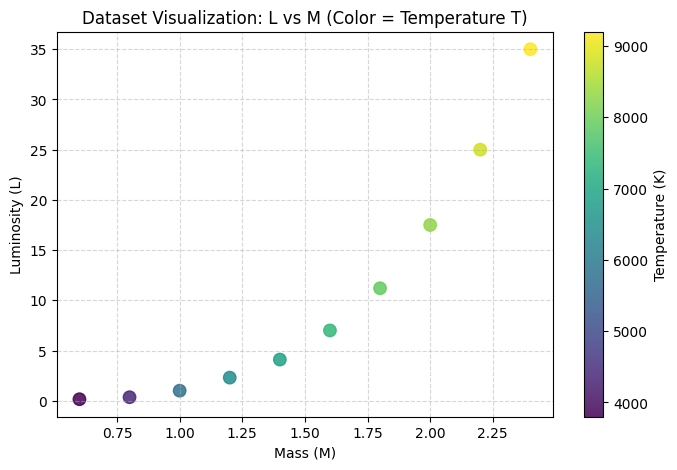

In [4]:
plt.figure(figsize=(8, 5))

sc = plt.scatter(
    M, L,
    c=T,              
    s=80,             
    alpha=0.85
)

plt.xlabel("Mass (M)")
plt.ylabel("Luminosity (L)")
plt.title("Dataset Visualization: L vs M (Color = Temperature T)")
plt.grid(True, linestyle="--", alpha=0.5)

cbar = plt.colorbar(sc)
cbar.set_label("Temperature (K)")

plt.show()


#### *Descripción*
En la gráfica se muestra la relación entre la masa estelar (M) y la luminosidad (L), donde el color de cada punto representa la temperatura efectiva de la estrella (T). Se observa claramente que, a medida que la masa aumenta, la luminosidad crece de forma acelerada, además al codificar la temperatura con el color, se aprecia que las estrellas de mayor masa también presentan temperaturas más altas, lo cual es consistente con el comportamiento físico esperado en estrellas. 

---

## 2. Feature Engineering: Build the Design Matrix X

### 2.1 Feature Map 


$$
X = [\, M,\ T,\ M^2,\ M\cdot T \,]
$$



In [5]:

import numpy as np

def construir_matriz(M, T, modelo="M3"):
    """
    Build design matrix X.
    Models:
      M1: [M, T]
      M2: [M, T, M^2]
      M3: [M, T, M^2, M*T]
    """
   
    M2 = M**2
    MT = M*T

    if modelo == "M1":
        X = np.column_stack([M, T])
    elif modelo == "M2":
        X = np.column_stack([M, T, M2])
    elif modelo == "M3":
        X = np.column_stack([M, T, M2, MT])
    else:
        raise ValueError("El modelo debe ser alguno de estos: 'M1', 'M2', 'M3'")

    return X

def mostrar_matriz(M, T, modelo="M3", rows=2):
    X = construir_matriz(M, T, modelo)
    
    if modelo == "M1":
        cols = ["M", "T"]
    elif modelo == "M2":
        cols = ["M", "T", "M^2"]
    elif modelo == "M3":
        cols = ["M", "T", "M^2", "M*T"]

    print(f"\nMatriz para el modelo {modelo}:")
    print("Columnas:", cols)
    print("Forma:", X.shape)
    print(f"Primeras {rows} filas:")
    print("[")

    for i in range(min(rows, X.shape[0])):
        row = X[i]
        formatted_row = "  [" + "  ".join(f"{val:8.3f}" for val in row) + "]"
        print(formatted_row)

    print("]")


mostrar_matriz(M, T, "M1")
mostrar_matriz(M, T, "M2")
mostrar_matriz(M, T, "M3")



Matriz para el modelo M1:
Columnas: ['M', 'T']
Forma: (10, 2)
Primeras 2 filas:
[
  [   0.600  3800.000]
  [   0.800  4400.000]
]

Matriz para el modelo M2:
Columnas: ['M', 'T', 'M^2']
Forma: (10, 3)
Primeras 2 filas:
[
  [   0.600  3800.000     0.360]
  [   0.800  4400.000     0.640]
]

Matriz para el modelo M3:
Columnas: ['M', 'T', 'M^2', 'M*T']
Forma: (10, 4)
Primeras 2 filas:
[
  [   0.600  3800.000     0.360  2280.000]
  [   0.800  4400.000     0.640  3520.000]
]


---

In [6]:
def normalize_features(X):
    media = np.mean(X, axis=0)          
    des_estandar = np.std(X, axis=0)        

    des_estandar = np.where(des_estandar == 0, 1, des_estandar)

    X_norm = (X - media) / des_estandar
    
    return X_norm, media, des_estandar

X_M3_norm, media, des_estandar = normalize_features(construir_matriz(M, T, "M3"))



---

## 3. Model, Loss, and Gradients (Vectorized)

### 3.1 Prediction


$$
\hat{L} = Xw + b
$$

### 3.2 Loss (MSE)


$$
J(w,b) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{L}^{(i)} - L^{(i)})^2
$$

### 3.3 Gradients (Vectorized)
 $e = \hat{L} - L$ where $e \in \mathbb{R}^{n}$.

Then:

$$
\nabla_w J = \frac{1}{n} X^T e
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n} e^{(i)}
$$




In [7]:
def predict(X, w, b):
    return X @ w + b

def error_mse(X,L,w,b):
    n = X.shape[0]
    L_hat = predict(X, w, b)
    cost = (1/(2 * n)) * np.sum((L_hat - L)**2)
    return cost

def calcular_gradiente (X, L, w, b):
    n = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - L
    dj_dw = (1/n) * (X.T @ error)
    dj_db = (1/n) * np.sum(error)
    
    return dj_dw, dj_db

---

## 4. Gradient Descent Training + Convergence


$$
w := w - \alpha\,\nabla_w J
$$

$$
b := b - \alpha\,\frac{\partial J}{\partial b}
$$



Training Polynomial Model M3: [M, T, M^2, M*T]
Iteration    0: cost =    72.4382
Iteration  100: cost =     3.2868
Iteration  200: cost =     1.6865
Iteration  300: cost =     1.1987
Iteration  400: cost =     1.0402
Iteration  500: cost =     0.9793
Iteration  600: cost =     0.9477
Iteration  700: cost =     0.9252
Iteration  800: cost =     0.9056
Iteration  900: cost =     0.8874
Iteration  999: cost =     0.8700

Learned parameters:
w = [-1.8948 -7.863  13.8977  6.3917]
b = 10.35999999999999


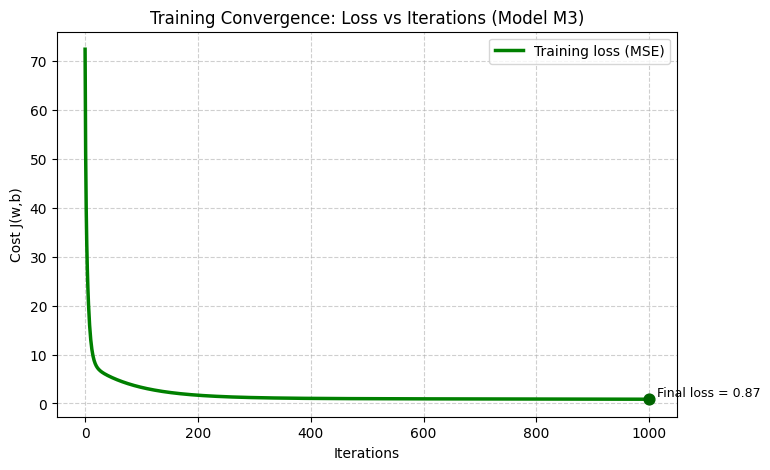

In [8]:
def gradient_descent(X, L, w_inicial, b_inicial, alpha, num_iteraciones, show=False, n_prints=10):

    w = w_inicial.copy()
    b = b_inicial
    history = []

    print_step = max(1, num_iteraciones // n_prints)

    for i in range(num_iteraciones):
        dj_dw, dj_db = calcular_gradiente(X, L, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        costo = error_mse(X, L, w, b)
        history.append(costo)

        if show and (i % print_step == 0 or i == num_iteraciones - 1):
            print(f"Iteration {i:4d}: cost = {costo:10.4f}")

    return w, b, history



print("Training Polynomial Model M3: [M, T, M^2, M*T]")

m = X_M3_norm.shape[1]
alpha = 0.1
num_iteraciones = 1000

w_inicial = np.zeros(m)
b_inicial = 0.0 

w_opt, b_opt, history = gradient_descent(X_M3_norm, L, w_inicial, b_inicial, alpha, num_iteraciones, show=True, n_prints=10)

print("\nLearned parameters:")
print("w =", w_opt)
print("b =", b_opt)



plt.figure(figsize=(8, 5))

plt.plot(
    range(len(history)),
    history,
    color="green",
    linewidth=2.5,
    label="Training loss (MSE)"
)

plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")
plt.title("Training Convergence: Loss vs Iterations (Model M3)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()


final_iter = len(history) - 1
final_loss = history[-1]

plt.scatter(final_iter, final_loss, color="darkgreen", s=60, zorder=5)
plt.text(
    final_iter, final_loss,
    f"  Final loss = {final_loss:.2f}",
    fontsize=9,
    verticalalignment="bottom"
)

plt.show()


---

## 5. Feature Selection Experiment (Mandatory)

### M1
$$
X = [M,\ T]
$$

### M2
$$
X = [M,\ T,\ M^2]
$$

### M3
$$
X = [M,\ T,\ M^2,\ M\cdot T]
$$


FEATURE SELECTION EXPERIMENT: M1 vs M2 vs M3

----------------------------------------------------------------------
Model M1 | Features: ['M', 'T']
Final loss (J) = 3.9047
b = 10.3600
w parameters:
     M : 24.907500
     T : -14.816821


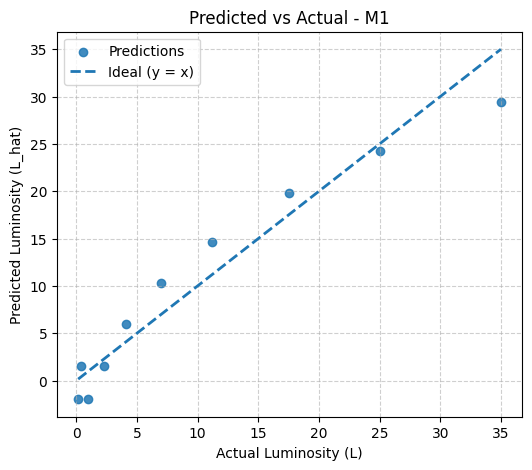


----------------------------------------------------------------------
Model M2 | Features: ['M', 'T', 'M^2']
Final loss (J) = 0.8762
b = 10.3600
w parameters:
     M : 0.194508
     T : -7.093754
   M^2 : 17.473972


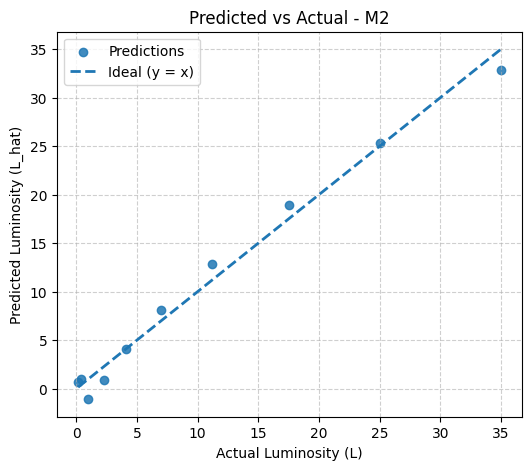


----------------------------------------------------------------------
Model M3 | Features: ['M', 'T', 'M^2', 'M*T']
Final loss (J) = 0.8700
b = 10.3600
w parameters:
     M : -1.894839
     T : -7.863034
   M^2 : 13.897731
   M*T : 6.391709


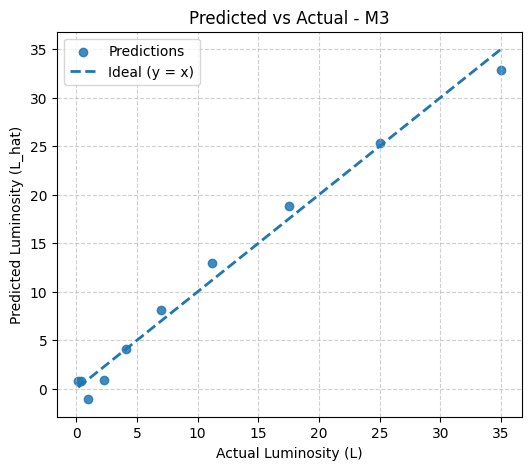

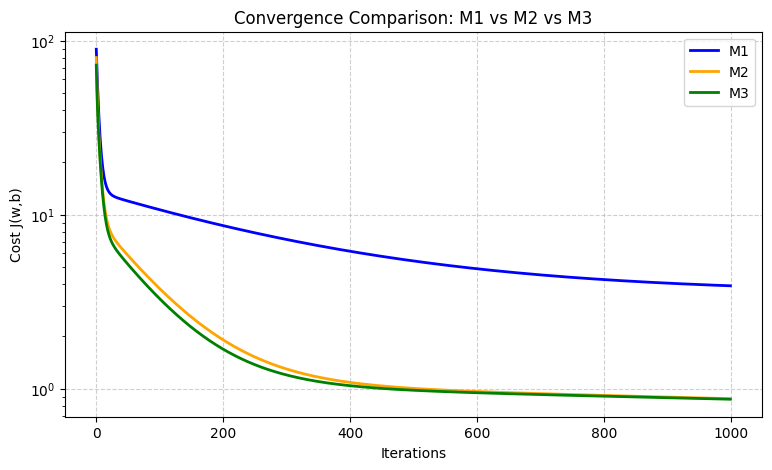

In [9]:
modelos = ["M1", "M2", "M3"]

alpha = 0.1
num_iteraciones = 1000

nombres_features = {
    "M1": ["M", "T"],
    "M2": ["M", "T", "M^2"],
    "M3": ["M", "T", "M^2", "M*T"]
}

resultados = []

print("FEATURE SELECTION EXPERIMENT: M1 vs M2 vs M3")

for modelo in modelos:
   
    X = construir_matriz(M, T, modelo=modelo)

    X_norm, media, des_estandar = normalize_features(X)


    if modelo == "M3":
        media_M3 = media
        des_M3 = des_estandar


    n_features = X_norm.shape[1]
    w_inicial = np.zeros(n_features)
    b_inicial = 0.0

    w_opt, b_opt, history = gradient_descent(X_norm, L, w_inicial, b_inicial, alpha, num_iteraciones,show=False)

    
    loss_final = history[-1]

    L_pred = predict(X_norm, w_opt, b_opt)

    resultados.append({
        "modelo": modelo,
        "features": nombres_features[modelo],
        "w": w_opt,
        "b": b_opt,
        "loss": loss_final,
        "L_pred": L_pred,
        "history": history
    })

    
    print("\n" + "-"*70)
    print(f"Model {modelo} | Features: {nombres_features[modelo]}")
    print(f"Final loss (J) = {loss_final:.4f}")
    print(f"b = {b_opt:.4f}")

    print("w parameters:")
    for fname, wval in zip(nombres_features[modelo], w_opt):
        print(f"  {fname:>4} : {wval:.6f}")

    plt.figure(figsize=(6, 5))
    plt.scatter(L, L_pred, alpha=0.85, label="Predictions")

    
    L_min, L_max = L.min(), L.max()
    plt.plot([L_min, L_max], [L_min, L_max], linestyle="--", linewidth=2, label="Ideal (y = x)")

    plt.xlabel("Actual Luminosity (L)")
    plt.ylabel("Predicted Luminosity (L_hat)")
    plt.title(f"Predicted vs Actual - {modelo}")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()



plt.figure(figsize=(9, 5))

colores = {
    "M1": "blue",
    "M2": "orange",
    "M3": "green"
}

for res in resultados:
    iters = range(len(res["history"]))
    costs = res["history"]

    plt.plot(
        iters,
        costs,
        color=colores[res["modelo"]],
        linewidth=2,
        label=res["modelo"]
    )

plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")
plt.title("Convergence Comparison: M1 vs M2 vs M3")
plt.grid(True, linestyle="--", alpha=0.6)
plt.yscale("log")
plt.legend()
plt.show()



#### *Análisis*

Al comparar los tres modelos, se observa que el modelo M1 presenta el mayor error, ya que solo utiliza masa y temperatura y no logra capturar correctamente el crecimiento acelerado de la luminosidad, especialmente para valores altos.

El modelo M2 mejora notablemente el ajuste al incluir el término $M^2$, lo que permite representar mejor la relación no lineal entre la masa y la luminosidad. Esto se muestra tanto en una menor pérdida como en predicciones más cercanas a los valores reales.

Finalmente, el modelo M3 es el que ofrece el mejor desempeño. Al incorporar el término $M\cdot T$, el modelo logra un ajuste más preciso y consistente en todo el rango de datos, alcanzando el menor valor de la función de costo.

---

## 6. Cost vs Interaction Coefficient (Mandatory)


$$
J \;\text{vs}\; w_{MT}
$$




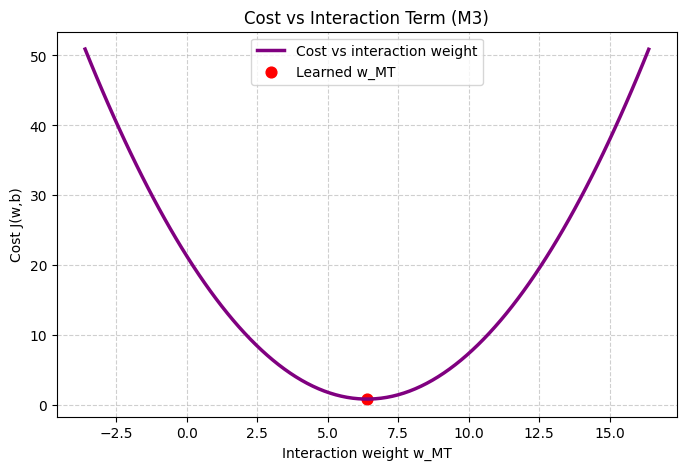

In [10]:

w_MT_entrenado = w_opt[3]

w_MT_values = np.linspace(w_MT_entrenado - 10, w_MT_entrenado + 10, 100)

costs = []

for w_MT in w_MT_values:
    w_test = w_opt.copy()
    w_test[3] = w_MT
    costo = error_mse(X_M3_norm, L, w_test, b_opt)
    costs.append(costo)


plt.figure(figsize=(8, 5))

plt.plot(
    w_MT_values,
    costs,
    color="purple",
    linewidth=2.5,
    label="Cost vs interaction weight"
)

plt.scatter(
    w_MT_entrenado,
    error_mse(X_M3_norm, L, w_opt, b_opt),
    color="red",
    s=60,
    label="Learned w_MT"
)

plt.xlabel("Interaction weight w_MT")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Interaction Term (M3)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


#### *Importancia de la interacción*

En la gráfica se observa que la función de costo tiene una forma de U, con un mínimo cerca del valor de $w_{MT}$ que aprendió el modelo durante el entrenamiento. Esto muestra que el término de interacción entre la masa y la temperatura es importante para el ajuste del modelo.

Como el mínimo es bastante marcado, esto quiere decir que pequeños cambios en el valor de $w_{MT}$ hacen que el error aumente rápidamente. Esto muestra que el modelo es sensible a este parámetro y que la interacción $M \cdot T$ aporta información importante para predecir la luminosidad.

Cuando el valor de $w_{MT}$ se aleja del valor ideal, el costo aumenta, esto muestra que eliminar o modificar este término empeora el desempeño del modelo.

---



## 7. Inference Demo (Mandatory)

- $M = 1.3$
- $T = 6600$


Inference Model M3
M = 1.3, T = 6600
Predicted luminosity L_hat = 2.5392

Valores de referencia del conjunto de datos (masas cercanas a 1.3):
M = 1.2, T = 6400, L = 2.3
M = 1.4, T = 6900, L = 4.1


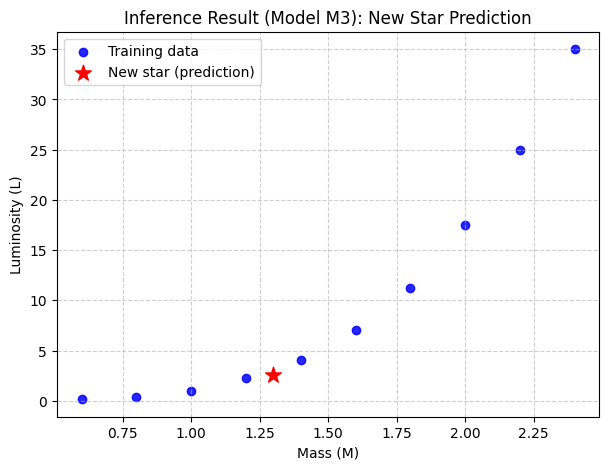

In [11]:

M_nueva = np.array([1.3])
T_nueva = np.array([6600])

X_nueva_M3 = construir_matriz(M_nueva, T_nueva, modelo="M3")

X_nueva_M3_norm = (X_nueva_M3 - media_M3) / des_M3

L_nueva_M3 = predict(X_nueva_M3_norm, w_opt, b_opt)

print("Inference Model M3")
print(f"M = {M_nueva[0]}, T = {T_nueva[0]}")
print(f"Predicted luminosity L_hat = {L_nueva_M3[0]:.4f}")

print("\nValores de referencia del conjunto de datos (masas cercanas a 1.3):")
for m_val, t_val, l_val in zip(M, T, L):
    if 1.2 <= m_val <= 1.4:
        print(f"M = {m_val}, T = {t_val}, L = {l_val}")


plt.figure(figsize=(7, 5))

plt.scatter(M, L, color="blue", alpha=0.85, label="Training data")

plt.scatter(
    M_nueva[0],
    L_nueva_M3[0],
    color="red",
    s=140,
    marker="*",
    label="New star (prediction)"
)

plt.xlabel("Mass (M)")
plt.ylabel("Luminosity (L)")
plt.title("Inference Result (Model M3): New Star Prediction")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()



---

#### *Conclusiones*

La luminosidad para la nueva estrella ( M=1.3, T=6600) es $L\approx$ 2.54, este resultado es razonable al compararla con los valores del conjunto de datos. En el dataset, para masas cercanas se observa que una estrella con M=1.2 tiene $L\approx$ 2.3 y otra con M=1.4 tiene $L\approx$ 4.1. La predicción cae entre estos dos valores, siguiendo la tendencia creciente de la luminosidad con la masa.
Además, el punto predicho se encuentra alineado con los datos observados en la gráfica, lo que indica que el modelo está realizando una interpolación coherente y no una estimación fuera de contexto.

#### *Limitaciones*
En este caso el riesgo de extrapolación es bajo, ya que la predicción se realiza dentro del rango de masas y temperaturas presentes en el conjunto de entrenamiento. Sin embargo, si se intentara predecir la luminosidad para valores de masa o temperatura fuera de este rango, la confiabilidad del modelo disminuiría, debido a que el comportamiento físico real puede volverse más complejo y no seguir la misma relación aprendida por el modelo.


---